# Exp1

## Using glove-wiki-gigaword-50

In [1]:
import gensim.downloader as api
model = api.load('glove-wiki-gigaword-50')
similar_words = model.most_similar(['king', 'woman'], ['man'])
print('king - man + woman is closest to:', similar_words[0][0])

king - man + woman is closest to: queen


## Using word2vec-google-news-300

In [2]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')
similar_words = model.most_similar(['king', 'woman'], ['man'])
print('king - man + woman is closest to:', similar_words[0][0])

king - man + woman is closest to: queen


# Exp2

5 similar words to king: [('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]


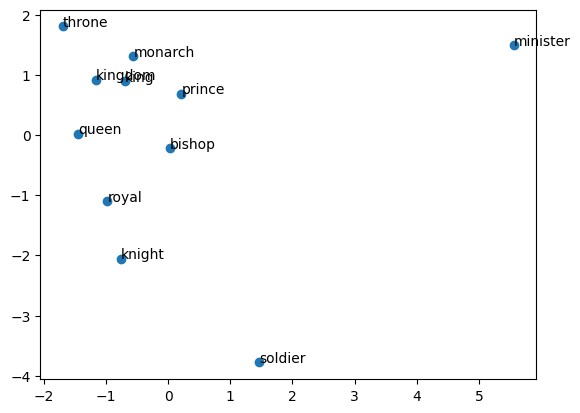

In [3]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model = api.load('glove-wiki-gigaword-50')

words = [
    'queen', 'king', 'throne', 'monarch',
    'kingdom', 'prince', 'minister', 'knight',
    'bishop', 'royal', 'soldier',
]
vectors = [model[word] for word in words]
vectors = PCA(2).fit_transform(vectors)

print("5 similar words to king:", model.most_similar('king', topn=5))

plt.scatter(vectors[:, 0], vectors[:, 1])
for i, word in enumerate(words):
    plt.text(vectors[i, 0], vectors[i, 1], word)
plt.show()

# Exp3

In [4]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

sentences = [
    "This is a legal document about contracts.",
    "The court will review this legal case.",
    "Medical professionals require specific training.",
    "This is a medical report of a patient.",
]

sentences = [simple_preprocess(sentence) for sentence in sentences]
model = Word2Vec(sentences, min_count=1).wv
print(model.most_similar('legal', topn=5))

[('specific', 0.19910520315170288), ('case', 0.17275597155094147), ('patient', 0.17022423446178436), ('document', 0.1528286635875702), ('report', 0.14595209062099457)]


# Exp4

In [5]:
import gensim.downloader as api
from transformers import pipeline

word_vectors = api.load('glove-wiki-gigaword-50')
generator = pipeline('text-generation', 'gpt2')

prompt = "Who is king"
print("Original prompt:", prompt)

similar_word = word_vectors.most_similar("king")[0][0]
enriched_prompt = prompt.replace("king", similar_word)
print("Enriched prompt:", enriched_prompt)

output = generator(prompt, max_length=50)[0]['generated_text']
enriched_output = generator(enriched_prompt, max_length=50)[0]['generated_text']

print("Original Response:\n", output)
print("Enriched Response:\n", enriched_output)

print("Length Comparison:", len(output), "vs", len(enriched_output))
print("Count of sentences:", output.count('.'), "vs", enriched_output.count('.'))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original prompt: Who is king
Enriched prompt: Who is prince


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original Response:
 Who is king of the world?"

"The king of kings. He is king of kings. He is king of kings."

"How do you know that?"

"I know he does not know that."

"How did he know that?"

"He did not know that."

"How did he know that?"

"He did not know that. He just did that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"He does not know that."

"How did he know that?"

"It is not possible that King Solomon is king of the world. He is not king of the world."

"It is not possible that King Solomon is king
Enriched Response:
 Who is prince of the kingdom of the heavens and of the earth?"

"Then is it?"

"It is, then, according to that which the Lord your God hath commanded us to do;"

And then th

# Exp5

In [6]:
import gensim.downloader as api

word_vectors = api.load('glove-wiki-gigaword-50')

seed = input("Enter seed word:")

similar_words = [word for word, score in word_vectors.most_similar(seed)]

paragraph = f"""
The {seed} was known for its connection with {similar_words[0]} and {similar_words[1]}.
People often relate this to {similar_words[2]} and {similar_words[3]}.
In many stories, {similar_words[4]} played important role alongside the {seed}.
"""

print("Generated paragraph:\n", paragraph)

Enter seed word: travel


Generated paragraph:
 
The travel was known for its connection with trips and travelers.
People often relate this to traveling and destinations.
In many stories, flights played important role alongside the travel.



# Exp6

In [7]:
from transformers import pipeline

analyzer = pipeline("sentiment-analysis")

reviews = [
    "Amazing!! Great product!",
    "Very disappointed with this product",
    "Terrible experiance",
    "Gets the job done",
]

for review in reviews:
    result = analyzer(review)[0]
    print(f"{review} -> {result['label']} ({result['score']:.4f})")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Amazing!! Great product! -> POSITIVE (0.9999)
Very disappointed with this product -> NEGATIVE (0.9998)
Terrible experiance -> NEGATIVE (0.9987)
Gets the job done -> POSITIVE (0.9995)


# Exp7

In [8]:
from transformers import pipeline

# summarizer = pipeline('summarization', facebook/bart-large-cnn')
summarizer = pipeline('text-generation', 'gpt2')

text = """
Summarize this:
Artificial Intelligence (AI) is a rapidly evolving field focused on creating intelligent machines.
It has impacted industries like healthcare, finance, and education. AI applications include chatbots,
self-driving cars, and recommendation systems. However, it also raises ethical concerns like bias
and job displacement.
"""

summary = summarizer(text, max_length=25)
# print("Summary:", summary[0]['summary_text'])
print("Summary:", summary[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=25) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summary: 
Summarize this:
Artificial Intelligence (AI) is a rapidly evolving field focused on creating intelligent machines.
It has impacted industries like healthcare, finance, and education. AI applications include chatbots,
self-driving cars, and recommendation systems. However, it also raises ethical concerns like bias
and job displacement.

As the field evolves, the more intelligent machines are created, the more the AI is able to do its job.

What are the most important characteristics of AI?

The human can do a lot more than a simple "work" task, for example.

The AI can also perform tasks like making a decision about whether to buy a new car or buy a new house.

The AI can also perform the same functions as a human, such as making a decision about which hospital to take care of, or whether or not to take an urgent care-call.

The AI can also perform a variety of other tasks, such as making a decision about the safety or health of certain people, or how to treat a particular dis

# Exp9

In [9]:
from pydantic import BaseModel
import wikipediaapi

class InstitutionDetails(BaseModel):
    founder: str | None
    founded: str | None
    summary: str | None

def from_wikipedia(name: str):
    wiki = wikipediaapi.Wikipedia(user_agent="ExamAgent/1.0 (example@email.com)", language='en')
    page = wiki.page(name)
    if not page.exists():
        raise ValueError("Institution page doesn't exists")
    text = page.text.lower()
    info = {}
    for line in text.split('\n'):
        if ':' in line:
            key_value = line.split(':')
            info[key_value[0].strip()] = key_value[-1].strip()
    return InstitutionDetails(
        founder = info.get('founder', None),
        founded = info.get('founded', None),
        summary = page.summary[:276]
    )

name = input("Enter institution name:").strip()
print("Details:\n", from_wikipedia(name))

Enter institution name: MIT


Details:
 founder=None founded=None summary='The Massachusetts Institute of Technology (MIT) is a private research university in Cambridge, Massachusetts, United States. Founded in 1861 to advance "useful knowledge", the university has played a significant role in the development of many areas of technology and science.'
